# Comparing the one-dimensional sinc-DVR basis to a finite-difference solution

In [1]:
import numba
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg

from quantum_systems import BasisSet, GeneralOrbitalSystem, ODQD, ODSincDVR
from configuration_interaction import CISD

In [24]:
num_dvr = 201
grid = np.linspace(-10, 10, num_dvr)
weight = np.abs(grid[1] - grid[0])
x = np.linspace(-10, 10, 1001)

l = 2
alpha = 1
a = 0.01

In [3]:
def sinc_basis(weight, point):
    return lambda x, w=weight, x_i=point: np.sinc((x - x_i) / w) / np.sqrt(w)

In [4]:
spf = [sinc_basis(weight, x_i) for x_i in grid]

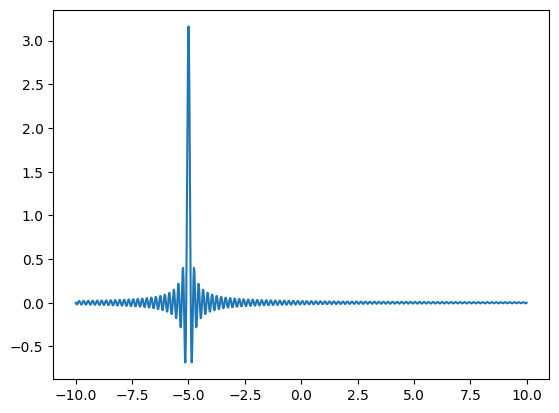

In [9]:
plt.plot(x, spf[50](x))
plt.show()

In [10]:
class HOPotential:
    def __init__(self, omega=1):
        self.omega = omega

    def __call__(self, x):
        return 0.5 * self.omega**2 * x**2

In [11]:
def kinetic_energy_mels(weight, i, j):
    if i == j:
        return np.pi**2 / (6 * weight**2)
    return (-1) ** (i - j) / (weight**2 * (i - j) ** 2)

In [12]:
t = np.zeros((num_dvr, num_dvr))

for i in range(num_dvr):
    for j in range(num_dvr):
        t[i, j] = kinetic_energy_mels(weight, i, j)

In [13]:
np.testing.assert_allclose(t, t.T)

In [14]:
potential = HOPotential()

In [15]:
v = potential(grid)

In [16]:
h = t + np.diag(v)

In [17]:
eps, C = scipy.linalg.eigh(h)

In [19]:
eps[:10]

array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5])

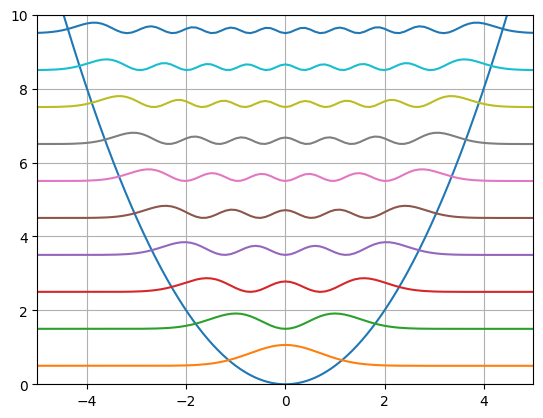

In [20]:
fig, ax = plt.subplots()

ax.plot(x, potential(x))

for i in range(10):
    ax.plot(grid, np.abs(C[:, i] / np.sqrt(weight)) ** 2 + eps[i])


ax.set_xlim(-5, 5)
ax.set_ylim(0, 10)
ax.grid()

In [21]:
def shielded_coulomb_operator(x_1, x_2, kappa, a):
    return kappa / np.sqrt((x_1 - x_2) ** 2 + a**2)

In [22]:
def coulomb_mels(grid, kappa, a):
    num_dvr = len(grid)

    u = np.zeros((num_dvr, num_dvr))

    for p in range(num_dvr):
        u[p, :] = shielded_coulomb_operator(grid[p], grid, kappa, a)

    return u

In [23]:
u_pq = coulomb_mels(grid, (alpha := 1), (a := 0.01))

In [25]:
u_pq_b = shielded_coulomb_operator(grid[None, :], grid[:, None], alpha, a)

In [32]:
u_pq_b.shape

(201, 201)

In [26]:
np.testing.assert_allclose(u_pq, u_pq_b)

In [28]:
C_new = C[:, :l]

In [29]:
C_new.shape

(201, 2)

In [30]:
h_new = np.einsum("pa, pq, qb -> ab", C_new, h, C_new)

In [31]:
np.diag(h_new)

array([0.5, 1.5])

In [33]:
u_new = np.einsum(
    "pa, qb, pc, qd, pq -> abcd", C_new, C_new, C_new, C_new, u_pq, optimize=True
)

In [35]:
system = GeneralOrbitalSystem(
    2, (odqd := ODQD(l, 10, 201, a=0.01, alpha=alpha, potential=potential)).copy_basis()
)
cisd_fd = CISD(system, verbose=True).compute_ground_state()
print(cisd_fd.energies[:10])

Number of states to create: 6
Size of a state in bytes: 8
Time spent setting up CISD space: 1.6634330749511719 sec


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Time spent constructing one-body Hamiltonian: 10.246575832366943 sec
Time spent constructing two-body Hamiltonian: 14.99262809753418 sec
Time spent diagonalizing Hamiltonian: 0.0011491775512695312 sec
CISD ground state energy: 2.7959527574778478
[ 2.79595276  2.79595276  2.79595276  4.76301223  8.33453475 10.31716172]


In [36]:
bs = BasisSet(l, dim=1)
bs.h = h_new
bs.u = u_new
bs.s = np.eye(l)

system_dvr = GeneralOrbitalSystem(2, bs)
cisd_dvr = CISD(system_dvr, verbose=True).compute_ground_state()
print(cisd_dvr.energies[:10])

Number of states to create: 6
Size of a state in bytes: 8
Time spent setting up CISD space: 5.984306335449219e-05 sec
Time spent constructing one-body Hamiltonian: 0.014632225036621094 sec
Time spent constructing two-body Hamiltonian: 0.00027108192443847656 sec
Time spent diagonalizing Hamiltonian: 0.00014638900756835938 sec
CISD ground state energy: 2.7971024595710263
[ 2.79710246  2.79710246  2.79710246  4.76424915  8.32905755 10.31198282]


I am unsure as to which method is best. As far as I know, the finite-difference basis is not variational, and that is perhaps best seen in the single-particle eigenenergies. We now the exact solution for the harmonic oscillator system, and the finite-difference basis undershoots these values. I would assume that the DVR-basis is in fact better, but the two-body energy is generally higher than in the finite-difference case. Looking at the one-body eigenenergies again we see that the DVR basis hits the exact value with very few grid points. This makes it much more appealing.

In [76]:
odsdvr = ODSincDVR(num_dvr, grid[-1], potential=potential, a=a, alpha=alpha)

In [77]:
np.testing.assert_allclose(odsdvr.u, u_pq)
np.testing.assert_allclose(odsdvr.h, h)

In [78]:
eps_o, C_o = scipy.linalg.eigh(odsdvr.h)

In [79]:
C_o_new = C_o[:, :l]

In [80]:
np.testing.assert_allclose(np.abs(C_o_new), np.abs(C_new), atol=1e-12)

In [81]:
u_o_new = odsdvr.transform_two_body_elements(odsdvr.u, C_o_new, np)

In [82]:
np.testing.assert_allclose(np.abs(u_new), np.abs(u_o_new), atol=1e-12)

In [83]:
@numba.njit
def _shielded_coulomb(x_1, x_2, alpha, a):
    return alpha / np.sqrt((x_1 - x_2) ** 2 + a**2)


@numba.njit
def _construct_inner_shielded_coulomb_integral(spf_2, grid_1, grid_2, alpha, a):
    num_grid_1_points = len(grid_1)
    num_grid_2_points = len(grid_2)
    l = len(spf_2)
    inner_integral = np.zeros((l, l, num_grid_1_points))

    for i in range(num_grid_1_points):
        coulomb = _shielded_coulomb(grid_1[i], grid_2, alpha, a)
        for q in range(l):
            for s in range(l):
                inner_integral[q, s, i] = np.trapz(
                    spf_2[q] * coulomb * spf_2[s],
                    grid_2,
                )

    return inner_integral


@numba.njit
def construct_shielded_coulomb_interaction_matrix_elements_dist(
    spf_1, spf_2, grid_1, grid_2, alpha, a
):
    l_1 = len(spf_1)
    l_2 = len(spf_2)
    inner_integral = _construct_inner_shielded_coulomb_integral(
        spf_2, grid_1, grid_2, alpha, a
    )
    u = np.zeros((l_1, l_2, l_1, l_2))

    for p in range(l_1):
        for q in range(l_2):
            for r in range(l_1):
                for s in range(l_2):
                    u[p, q, r, s] = np.trapz(
                        spf_1[p] * inner_integral[q, s] * spf_1[r],
                        grid_1,
                    )

    return u

In [84]:
u_dvr_fd = construct_shielded_coulomb_interaction_matrix_elements_dist(
    C_new.T / np.sqrt(weight), C_new.T / np.sqrt(weight), grid, grid, alpha, a
)

In [85]:
np.testing.assert_allclose(np.abs(u_dvr_fd), np.abs(u_new), atol=1e-12)

In [86]:
for p in range(l):
    for q in range(l):
        for r in range(l):
            for s in range(l):
                print(u_dvr_fd[p, q, r, s], u_new[p, q, r, s])

6.32905754883574 6.329057548835694
6.121300593431975e-15 4.080936977235439e-15
5.7847674929023455e-15 4.504643186242774e-15
2.7659775446323653 2.765977544632345
6.567124316023353e-15 4.080936977235439e-15
3.563080004203389 3.563080004203363
2.765977544632365 2.765977544632345
-1.8527672273621877e-14 -1.9796664307847323e-14
5.7839527890677525e-15 4.504643186242774e-15
2.765977544632365 2.765977544632345
3.5630800042033894 3.5630800042033623
-1.795213543872852e-14 -1.986952269383835e-14
2.765977544632365 2.765977544632345
-1.8194579955252413e-14 -1.9796664307847323e-14
-1.7501134196150342e-14 -1.986952269383835e-14
4.747174415814448 4.747174415814416


In [87]:
for p in range(l):
    for q in range(l):
        for r in range(l):
            for s in range(l):
                print((p, q, r, s), odqd.u[p, q, r, s].real, u_new[p, q, r, s])

(0, 0, 0, 0) 6.332934867163099 6.329057548835694
(0, 0, 0, 1) -6.002770222525832e-15 4.080936977235439e-15
(0, 0, 1, 0) -6.408235186554682e-15 4.504643186242774e-15
(0, 0, 1, 1) 2.7692909968701915 2.765977544632345
(0, 1, 0, 0) -5.825596748566934e-15 4.080936977235439e-15
(0, 1, 0, 1) 3.567120713357795 3.563080004203363
(0, 1, 1, 0) 2.7692909968701915 2.765977544632345
(0, 1, 1, 1) 5.787383316195493e-15 -1.9796664307847323e-14
(1, 0, 0, 0) -6.097393957581644e-15 4.504643186242774e-15
(1, 0, 0, 1) 2.7692909968701915 2.765977544632345
(1, 0, 1, 0) 3.567120713357796 3.5630800042033623
(1, 0, 1, 1) 5.452543013048135e-15 -1.986952269383835e-14
(1, 1, 0, 0) 2.7692909968701915 2.765977544632345
(1, 1, 0, 1) 5.848030877080219e-15 -1.9796664307847323e-14
(1, 1, 1, 0) 5.446978893824095e-15 -1.986952269383835e-14
(1, 1, 1, 1) 4.750993000135064 4.747174415814416


In [88]:
u_lol = construct_shielded_coulomb_interaction_matrix_elements_dist(
    odqd.spf[:1].real, odqd.spf[:1].real, odqd.grid, odqd.grid, alpha, a
)

In [89]:
u_lol

array([[[[6.33293487]]]])

In [90]:
np.testing.assert_allclose(np.abs(u_new), np.abs(odqd.u), atol=1e-3)

AssertionError: 
Not equal to tolerance rtol=1e-07, atol=0.001

Mismatched elements: 8 / 16 (50%)
Max absolute difference: 0.00404071
Max relative difference: 2.64780607
 x: array([[[[6.329058e+00, 4.080937e-15],
         [4.504643e-15, 2.765978e+00]],
...
 y: array([[[[6.332935e+00, 6.002770e-15],
         [6.408235e-15, 2.769291e+00]],
...

In [91]:
np.abs(u_new.ravel())

array([6.32905755e+00, 4.08093698e-15, 4.50464319e-15, 2.76597754e+00,
       4.08093698e-15, 3.56308000e+00, 2.76597754e+00, 1.97966643e-14,
       4.50464319e-15, 2.76597754e+00, 3.56308000e+00, 1.98695227e-14,
       2.76597754e+00, 1.97966643e-14, 1.98695227e-14, 4.74717442e+00])

In [92]:
np.abs(odqd.u.real.ravel())

array([6.33293487e+00, 6.00277022e-15, 6.40823519e-15, 2.76929100e+00,
       5.82559675e-15, 3.56712071e+00, 2.76929100e+00, 5.78738332e-15,
       6.09739396e-15, 2.76929100e+00, 3.56712071e+00, 5.45254301e-15,
       2.76929100e+00, 5.84803088e-15, 5.44697889e-15, 4.75099300e+00])

In [93]:
np.testing.assert_allclose(np.abs(u_dvr_fd), np.abs(odqd.u), atol=1e-3)

AssertionError: 
Not equal to tolerance rtol=1e-07, atol=0.001

Mismatched elements: 8 / 16 (50%)
Max absolute difference: 0.00404071
Max relative difference: 2.29243353
 x: array([[[[6.329058e+00, 6.121301e-15],
         [5.784767e-15, 2.765978e+00]],
...
 y: array([[[[6.332935e+00, 6.002770e-15],
         [6.408235e-15, 2.769291e+00]],
...

In short there seems to be a difference for Coulomb interaction matrix elements when using DVR and FD. Computing the matrix elements using either DVR directly and then transforming to the eigenbasis of $\hat{h}$, or transforming the basis and then computing the Coulomb matrix elements using the same numerical integration scheme as for the FD-basis gives the same results.

However, FD and DVR differ. In particular, it seems that the number of grid points greatly changes the values for the Coulomb elements. For the same number of grid points they are comparable.